# Lab 08 — Controlador de Atraso de Fase e PI

**Módulo 02 · Semana 8 · Laboratório de Controle Automático (Ifes Guarapari)**

Neste laboratório você vai:
1. Ver o **mecanismo do atraso** em ação: dobrar $k_v$ sem mover os polos (e o preço: convergência lenta);
2. Implementar `projetar_atraso` e medir o **trade-off do fator** no overshoot;
3. Projetar um **PI para planta de 3ª ordem tipo 0** e ajustar o zero;
4. Resolver o **desafio da planta instável**: provar por Routh que não existe solução com aquele PI.

Teoria de referência: `teoria_modulo2.md`, seção **§2.4**.

In [1]:
# %% IMPORTS (rode esta célula primeiro)
!pip install --quiet control==0.10.2
import control as ct
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (9, 4)
plt.rcParams['axes.grid'] = True

def step(G, t):
    t, y = ct.step_response(G, t)
    return np.asarray(t), np.asarray(y)

def medir(T, t=None):
    if t is None: t = np.linspace(0, 50, 50000)
    t, y = step(T, t)
    yss = y[-1]
    Mp = 100*(y.max()-yss)/yss; tp = t[np.argmax(y)]
    tr = t[np.argmax(y >= yss)]
    fora = np.where(np.abs(y-yss) > 0.05*abs(yss))[0]
    ts = t[fora[-1]] if len(fora) else 0.0
    return dict(Mp=Mp, tp=tp, tr=tr, ts=ts, yss=yss)

def projetar_atraso(k, sd, fator):
    """Atraso C(s) = k(s+a)/(s+b): zero em |Re(sd)|/10, polo = zero/fator."""
    a = -sd.real/10
    b = a/fator
    return k*ct.tf([1, a], [1, b]), a, b

print('python-control', ct.__version__)


[notice] A new release of pip is available: 25.0.1 -> 26.2
[notice] To update, run: pip install --upgrade pip


python-control 0.10.2


## Parte 1 — O mecanismo: dobrar $k_v$ sem mover os polos

$G(s) = \dfrac{1}{s(s+3{,}2)}$ com P, $k = 7{,}4$: polos $-1{,}6 \pm 2{,}2j$, $k_v = 2{,}31$, $e_{ss}(\text{rampa}) = 0{,}43$.
Acrescentamos $C_{at} = \dfrac{s+0{,}02}{s+0{,}01}$ (fator 2) e comparamos **polos, degrau e erro à rampa**:

polos sem atraso: [-1.6+2.2j -1.6-2.2j]
polos com atraso: [-1.595 +2.1964j -1.595 -2.1964j -0.0201+0.j    ]


ess(rampa) sem atraso = 0.432 | com atraso = 0.220


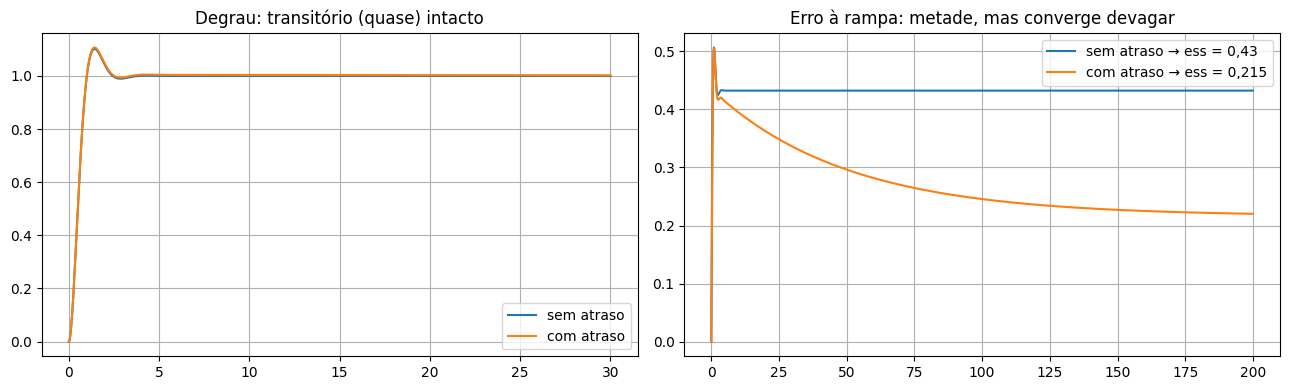

In [2]:
G = ct.tf([1], [1, 3.2, 0])
T0 = ct.feedback(7.4*G, 1)
Cat = ct.tf([1, 0.02], [1, 0.01])
T1 = ct.feedback(7.4*Cat*G, 1)
print('polos sem atraso:', np.round(ct.poles(T0), 4))
print('polos com atraso:', np.round(ct.poles(T1), 4))

t = np.linspace(0, 30, 30000)
# erro à rampa: E(s) = R(s)/(1+CG), R = 1/s^2 → simulamos a resposta à rampa do sistema E
E0 = 1/(1 + 7.4*G)
E1 = 1/(1 + 7.4*Cat*G)
tt = np.linspace(0, 200, 40000)
_, e0 = ct.forced_response(E0, tt, tt)   # entrada r(t) = t (rampa)
_, e1 = ct.forced_response(E1, tt, tt)
e0, e1 = np.asarray(e0), np.asarray(e1)
fig, axs = plt.subplots(1, 2, figsize=(13, 4))
axs[0].plot(*step(T0, t), label='sem atraso')
axs[0].plot(*step(T1, t), label='com atraso')
axs[0].set_title('Degrau: transitório (quase) intacto'); axs[0].legend()
axs[1].plot(tt, e0, label='sem atraso → ess = 0,43')
axs[1].plot(tt, e1, label='com atraso → ess = 0,215')
axs[1].set_title('Erro à rampa: metade, mas converge devagar'); axs[1].legend()
plt.tight_layout()
print(f'ess(rampa) sem atraso = {e0[-1]:.3f} | com atraso = {e1[-1]:.3f}')

**✏️ Responda:** o 3º polo de malha fechada ($-0{,}0201$) é quem manda na "cauda" do erro.
Por que ele não estraga o transitório? (Dica: quem está colado nele?)

## Parte 2 — O trade-off do fator

Mesma planta, zero do atraso em $-0{,}16$ (regra do 1/10). Fatores 2 e 10 — e um fator 10
com o par **afastado** da origem, $(s+0{,}8)/(s+0{,}08)$ (Exercício 2.4.2):

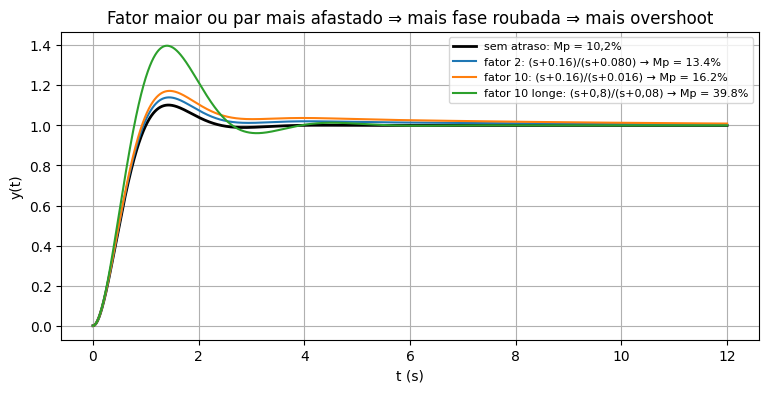

In [3]:
sd = -1.6 + 2.2j
t = np.linspace(0, 12, 12000)
plt.plot(*step(T0, t), 'k-', lw=2, label='sem atraso: Mp = 10,2%')
configs = [('fator 2', 2, None), ('fator 10', 10, None)]
for nome, fator, _ in configs:
    C_at, a, b = projetar_atraso(7.4, sd, fator)
    T = ct.feedback(C_at*G, 1)
    m = medir(T, t)
    plt.plot(*step(T, t), label=f'{nome}: (s+{a:.2f})/(s+{b:.3f}) → Mp = {m["Mp"]:.1f}%')
C_longe = 7.4*ct.tf([1, 0.8], [1, 0.08])
Tl = ct.feedback(C_longe*G, 1)
ml = medir(Tl, t)
plt.plot(*step(Tl, t), label=f'fator 10 longe: (s+0,8)/(s+0,08) → Mp = {ml["Mp"]:.1f}%')
plt.xlabel('t (s)'); plt.ylabel('y(t)'); plt.legend(fontsize=8)
plt.title('Fator maior ou par mais afastado ⇒ mais fase roubada ⇒ mais overshoot');

**✏️ Responda:** calcule à mão a contribuição de fase dos dois primeiros pares no ponto
$-1{,}6+2{,}2j$ (confira: $-1{,}43°$ e $-2{,}55°$) e relacione com o aumento do overshoot.

## Parte 3 — PI para 3ª ordem do tipo 0

$G(s) = \dfrac{20}{(s+1)(s+2)(s+10)}$, requisitos $M_p = 16{,}3\,\%$ e $e_{ss}(\text{degrau}) = 0$
(Exercício 2.4.3). Erro nulo com planta tipo 0 ⇒ **só o PI** (polo na origem sobe o tipo).
Duas posições de zero: o chute $-0{,}123$ e o ajuste $-0{,}73$.

zero −0.123: polos MF = [-10.532+0.j     -1.19 +2.094j  -1.19 -2.094j  -0.088+0.j   ]


zero −0.73: polos MF = [-10.504+0.j     -0.914+1.931j  -0.914-1.931j  -0.667+0.j   ]


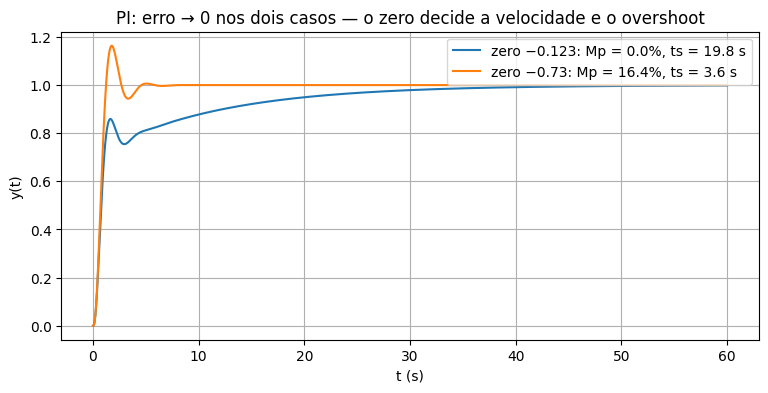

In [4]:
G = ct.tf([20], [1, 13, 32, 20])
t = np.linspace(0, 60, 60000)
for z in [0.123, 0.73]:
    Cpi = 2.19*ct.tf([1, z], [1, 0])
    T = ct.feedback(Cpi*G, 1)
    m = medir(T, t)
    plt.plot(*step(T, t), label=f'zero −{z}: Mp = {m["Mp"]:.1f}%, ts = {m["ts"]:.1f} s')
    print(f'zero −{z}: polos MF = {np.round(ct.poles(T), 3)}')
plt.xlabel('t (s)'); plt.ylabel('y(t)'); plt.legend()
plt.title('PI: erro → 0 nos dois casos — o zero decide a velocidade e o overshoot');

**✏️ Responda:** por que o zero $-0{,}123$ elimina o overshoot? (Olhe o polo de MF perto dele.)
Por que dizemos que a regra do 1/10 é "chute inicial, não dogma"?

## Parte 4 — DESAFIO: o PI e a planta instável

$G(s) = \dfrac{20}{(s-1)(s+2)(s+10)}$ (polo em $+1$!). Tente o PI com **zero em $-0{,}5$**:
$C = k\dfrac{s+0{,}5}{s}$. A equação característica é

$$s(s-1)(s+2)(s+10) + 20k(s+0{,}5) = 0 \;\Rightarrow\; s^4 + 11s^3 + 8s^2 + (20k-20)s + 10k = 0$$

e a linha $s^1$ de Routh contém a expressão $-400k^2 + 1350k - 2160$.
**Se ela for negativa para todo $k$, não existe $k$ que estabilize com esse zero.** Verifique — e
depois investigue o que muda com o zero em $-0{,}123$:

discriminante = -1633500 < 0 → a parábola NUNCA toca o eixo: sempre negativa


zero −0.5: NENHUM k estabiliza — Routh confirmado


zero −0.123: estabiliza para k ∈ [1.26, 4.42]
polos MF com zero −0,123 e k = 2,19: [-10.448+0.j     -0.156+1.459j  -0.156-1.459j  -0.239+0.j   ]


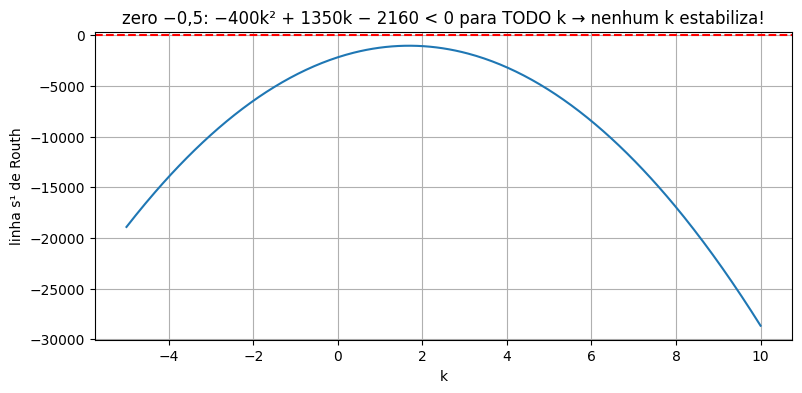

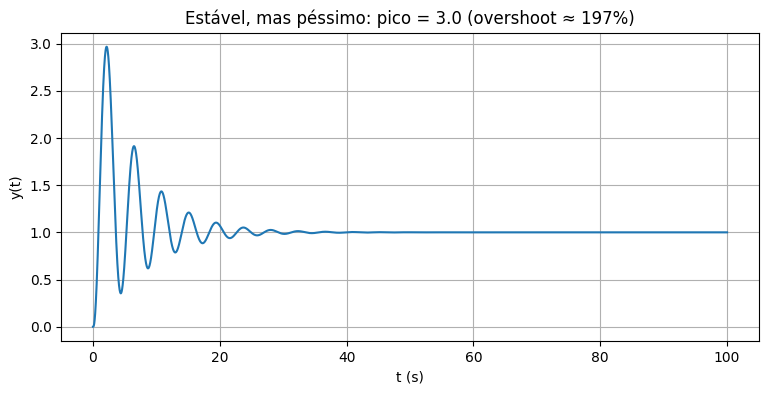

In [5]:
k = np.linspace(-5, 10, 400)
linha_s1 = -400*k**2 + 1350*k - 2160
plt.plot(k, linha_s1); plt.axhline(0, color='r', ls='--')
plt.xlabel('k'); plt.ylabel('linha s¹ de Routh')
plt.title('zero −0,5: −400k² + 1350k − 2160 < 0 para TODO k → nenhum k estabiliza!')
disc = 1350**2 - 4*400*2160
print(f'discriminante = {disc} < 0 → a parábola NUNCA toca o eixo: sempre negativa')

# varredura numérica de estabilidade para os dois zeros
Ginst = ct.tf([20], [1, 11, 8, -20])
for z in [0.5, 0.123]:
    estaveis = []
    for kk in np.linspace(0.01, 20, 400):
        Cpi = kk*ct.tf([1, z], [1, 0])
        if all(p.real < 0 for p in ct.poles(ct.feedback(Cpi*Ginst, 1))):
            estaveis.append(kk)
    if estaveis:
        print(f'zero −{z}: estabiliza para k ∈ [{estaveis[0]:.2f}, {estaveis[-1]:.2f}]')
    else:
        print(f'zero −{z}: NENHUM k estabiliza — Routh confirmado')

# "mas com zero −0,123 estabiliza!" — estabilidade NÃO é desempenho:
Cpi = 2.19*ct.tf([1, 0.123], [1, 0])
Ti = ct.feedback(Cpi*Ginst, 1)
print('polos MF com zero −0,123 e k = 2,19:', np.round(ct.poles(Ti), 3))
tt, y = step(Ti, np.linspace(0, 100, 100000))
plt.figure(); plt.plot(tt, y); plt.xlabel('t (s)'); plt.ylabel('y(t)')
plt.title(f'Estável, mas péssimo: pico = {y.max():.1f} (overshoot ≈ {100*(y.max()-1):.0f}%)');

**✏️ Responda:**
1. Esboce o LGR de $\dfrac{(s+0{,}5)}{s(s-1)(s+2)(s+10)}$ e explique **geometricamente** por que
   o zero em $-0{,}5$ não tira o ramo do polo $+1$ do semiplano direito.
2. Com o zero em $-0{,}123$, Routh dá $-400k^2 + 2262k - 2160$, positivo para $1{,}22 < k < 4{,}44$.
   Por que mesmo assim esse projeto não presta? (Olhe os polos de MF simulados.)
3. Complete a frase: "a posição do zero decide até se ______ solução; e estabilidade não é ______.

## Sua vez (entregue no relatório)

1. **Projeto literal (§2.4.5):** para $G(s) = \dfrac{3}{s(s+6)}$, projete o atraso para
   $M_p = 15\,\%$ com fator 4 ($k = a^2/(1{,}07b)$, zero em $a/20$, polo em $a/80$... adapte
   ao fator 4). Simule e meça $M_p$ e $k_v$ antes e depois.
2. **PI × atraso:** para a planta da Parte 1, projete um PI com zero em $-0{,}32$ e compare
   com o atraso de fator 10: erro à rampa nos dois casos? Preço no transitório?
3. **Estabilidade primeiro:** explique, usando o LGR de $\dfrac{20}{(s-1)(s+2)(s+10)}$,
   por que **nem mesmo o P** estabiliza essa planta (dica: onde começam os ramos?).